# Análise Temporal e Modelo SARIMA do Desemprego nos EUA

## Imports

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
from sklearn.metrics import mean_absolute_error

import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings('ignore')

## Apresentação da Base

A base de dados utilizada foi extraída do [Kaggle](https://www.kaggle.com/datasets/justin2028/unemployment-in-america-per-us-state), sendo originalmente obtida a partir do Bureau of Labor Statistics (BLS), agência governamental dos Estados Unidos responsável pela coleta e divulgação de estatísticas relacionadas ao mercado de trabalho e à economia do país.  

Os dados pertencem à seção *Local Area Unemployment Statistics (LAUS)*, programa oficial do BLS que disponibiliza indicadores mensais de emprego e desemprego para estados e áreas administrativas americanas desde janeiro de 1976. A utilização dessa fonte garante maior confiabilidade e padronização estatística, uma vez que se trata de uma base oficial amplamente utilizada em estudos econômicos e análises de séries temporais.

### Contexto da Análise

A base reúne informações relacionadas ao mercado de trabalho norte-americano, contendo dados sobre população economicamente ativa, emprego e desemprego em diferentes estados e regiões dos Estados Unidos ao longo do tempo.  

Neste trabalho, os dados foram utilizados para construir uma série temporal da taxa de desemprego agregada dos Estados Unidos, permitindo analisar o comportamento do desemprego ao longo dos anos e identificar padrões temporais, tendências e possíveis variações sazonais associadas ao cenário econômico do país.

### Descrição dos Dados

| Coluna | Descrição |
|---|---|
| `FIPS Code` | Identificador numérico do padrão Federal Information Processing Standards (FIPS) para o estado ou área analisada. |
| `State/Area` | Nome do estado ou área correspondente ao registro. |
| `Year` | Ano referente às estatísticas registradas. |
| `Month` | Mês referente às estatísticas registradas. |
| `Total Civilian Non-Institutional Population in State/Area` | Quantidade total de civis não institucionalizados residentes no estado ou área. |
| `Total Civilian Labor Force in State/Area` | Quantidade total de civis aptos ao trabalho que residem no estado ou área. |
| `Percent (%) of State/Area's Population` | Percentual da população civil não institucionalizada que faz parte da força de trabalho. |
| `Total Employment in State/Area` | Quantidade total de civis empregados no estado ou área. |
| `Percent (%) of Labor Force Employed in State/Area` | Percentual da força de trabalho que está empregada. |
| `Total Unemployment in State/Area` | Quantidade total de civis desempregados no estado ou área. |


### Variável Temporal Utilizada

A variável temporal utilizada na análise será a coluna `date`, que será construída a partir da combinação das variáveis `Year` e `Month`. Cada observação representará um mês específico da série temporal, permitindo acompanhar a evolução da taxa de desemprego ao longo do tempo.

### Variável Analisada

A variável analisada será a taxa de desemprego (`unemployment_rate`), que será construída a partir da relação entre o total de desempregados e o total da força de trabalho civil.

### Frequência da Série

A série temporal possui frequência mensal, uma vez que os dados são disponibilizados mensalmente pelo Bureau of Labor Statistics (BLS).

### Período Coberto pela Série

A base cobre o período entre janeiro de 1976 e setembro de 2025, contemplando aproximadamente cinco décadas de informações sobre o mercado de trabalho norte-americano.

### Quantidade de Observações

A base original possui 31.747 registros distribuídos entre diferentes estados e áreas administrativas dos Estados Unidos. Porém Após o agrupamento dos dados por mês e a construção da série temporal agregada, a base final utilizada na análise possuirá uma observação para cada mês do período analisado, totalizando 593 observações mensais.

### Possíveis Problemas Encontrados nos Dados

Durante a análise inicial da base, foram identificados alguns aspectos que exigirão tratamento na etapa de preparação dos dados:

- Necessidade de construção de uma variável temporal adequada para séries temporais;
- Necessidade de construção da váriavel de taxa de desemprego;
- Dados distribuídos entre diferentes estados e áreas administrativas, exigindo agregação.

In [305]:
df = pd.read_csv('Unemployment in America Per US State.csv', na_values=['–'])
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2


In [306]:
df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
0,1,Alabama,1976,1,"2,605,000","1,486,509",57.1,"1,387,606",53.3,"98,903",6.7,1976-01-01
1,2,Alaska,1976,1,"232,000","160,709",69.3,"149,226",64.3,"11,483",7.1,1976-01-01
2,4,Arizona,1976,1,"1,621,000","963,980",59.5,"865,261",53.4,"98,719",10.2,1976-01-01
3,5,Arkansas,1976,1,"1,536,000","889,912",57.9,"825,233",53.7,"64,679",7.3,1976-01-01
4,6,California,1976,1,"15,621,000","9,770,553",62.5,"8,873,133",56.8,"897,420",9.2,1976-01-01


In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31747 entries, 0 to 31746
Data columns (total 12 columns):
 #   Column                                                     Non-Null Count  Dtype         
---  ------                                                     --------------  -----         
 0   FIPS Code                                                  31747 non-null  int64         
 1   State/Area                                                 31747 non-null  object        
 2   Year                                                       31747 non-null  int64         
 3   Month                                                      31747 non-null  int64         
 4   Total Civilian Non-Institutional Population in State/Area  31694 non-null  object        
 5   Total Civilian Labor Force in State/Area                   31694 non-null  object        
 6   Percent (%) of State/Area's Population                     31694 non-null  float64       
 7   Total Employment in State/Area 

In [308]:
df.isna().sum()

FIPS Code                                                     0
State/Area                                                    0
Year                                                          0
Month                                                         0
Total Civilian Non-Institutional Population in State/Area    53
Total Civilian Labor Force in State/Area                     53
Percent (%) of State/Area's Population                       53
Total Employment in State/Area                               53
Percent (%) of Labor Force Employed in State/Area            53
Total Unemployment in State/Area                             53
Percent (%) of Labor Force Unemployed in State/Area          53
date                                                          0
dtype: int64

In [309]:
df.describe()

,FIPS Code,Year,Month,Percent (%) of State/Area's Population,Percent (%) of Labor Force Employed in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
count,31747.000000,31747.000000,31747.000000,31694.000000,31694.000000,31694.000000,31747
mean,990.830189,2000.459098,6.490818,65.370221,61.617158,5.784909,2000-11-30 11:56:23.639399040
min,1.000000,1976.000000,1.000000,51.100000,41.700000,1.700000,1976-01-01 00:00:00
25%,17.000000,1988.000000,3.000000,62.600000,58.600000,4.200000,1988-06-01 00:00:00
50%,30.000000,2000.000000,6.000000,65.700000,61.700000,5.400000,2000-12-01 00:00:00
75%,42.000000,2013.000000,9.000000,68.300000,65.000000,7.000000,2013-06-01 00:00:00
max,51000.000000,2025.000000,12.000000,75.800000,73.200000,30.500000,2025-11-01 00:00:00
std,6935.150440,14.408346,3.447659,4.309141,4.689543,2.212960,NaN


In [310]:
# Ver quais são os meses que contêm dados faltantes
df.loc[df.isna().any(axis=1), 'date'].unique()

<DatetimeArray>
['2025-10-01 00:00:00']
Length: 1, dtype: datetime64[ns]

In [311]:
# Remover as datas que vêm depois de '2025-10-01'
df = df[df['date'] < '2025-10-01']
df.isna().sum()

FIPS Code                                                    0
State/Area                                                   0
Year                                                         0
Month                                                        0
Total Civilian Non-Institutional Population in State/Area    0
Total Civilian Labor Force in State/Area                     0
Percent (%) of State/Area's Population                       0
Total Employment in State/Area                               0
Percent (%) of Labor Force Employed in State/Area            0
Total Unemployment in State/Area                             0
Percent (%) of Labor Force Unemployed in State/Area          0
date                                                         0
dtype: int64

In [312]:
df['Total Unemployment in State/Area'] = pd.to_numeric(
    df['Total Unemployment in State/Area']
    .str.replace(',', '', regex=False),
    errors='coerce'
)

df['Total Civilian Labor Force in State/Area'] = pd.to_numeric(
    df['Total Civilian Labor Force in State/Area']
    .str.replace(',', '', regex=False),
    errors='coerce'
)

df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area,date
0,1,Alabama,1976,1,"2,605,000",1486509,57.1,"1,387,606",53.3,98903,6.7,1976-01-01
1,2,Alaska,1976,1,"232,000",160709,69.3,"149,226",64.3,11483,7.1,1976-01-01
2,4,Arizona,1976,1,"1,621,000",963980,59.5,"865,261",53.4,98719,10.2,1976-01-01
3,5,Arkansas,1976,1,"1,536,000",889912,57.9,"825,233",53.7,64679,7.3,1976-01-01
4,6,California,1976,1,"15,621,000",9770553,62.5,"8,873,133",56.8,897420,9.2,1976-01-01


In [313]:
series = (
    df.groupby('date')
    .agg({
        'Total Unemployment in State/Area': 'sum',
        'Total Civilian Labor Force in State/Area': 'sum'
    })
)
 
series['unemployment_rate'] = (
    series['Total Unemployment in State/Area'] /
    series['Total Civilian Labor Force in State/Area']
) * 100

series = series.drop(columns=['Total Unemployment in State/Area', 'Total Civilian Labor Force in State/Area'])

series.tail()

,unemployment_rate
date,
2025-05-01,4.258522
2025-06-01,4.244684
2025-07-01,4.258767
2025-08-01,4.266550
2025-09-01,4.314338


In [314]:
series.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 597 entries, 1976-01-01 to 2025-09-01
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   unemployment_rate  597 non-null    float64
dtypes: float64(1)
memory usage: 9.3 KB


In [315]:
series.tail()

,unemployment_rate
date,
2025-05-01,4.258522
2025-06-01,4.244684
2025-07-01,4.258767
2025-08-01,4.266550
2025-09-01,4.314338


## Tratamento e Preparação dos Dados

Após a análise inicial da base, foram realizados tratamentos para adequar os dados à modelagem de séries temporais.

### Conversão da Coluna Temporal

A variável temporal utilizada na análise foi a coluna `date`, construída a partir da combinação das variáveis `Year` e `Month`. Cada observação representa um mês específico da série temporal.

### Conversão de Variáveis Numéricas

Algumas variáveis quantitativas estavam armazenadas no formato textual (`object`) e continham separadores de milhar (vírgulas). Dessa forma, foi necessário realizar a remoção desses caracteres e converter os valores para formato numérico utilizando a função `pd.to_numeric()`.

As principais variáveis tratadas foram:
- `Total Unemployment in State/Area`;
- `Total Civilian Labor Force in State/Area`.

### Ordenação Temporal e Definição do Índice

Após a criação da coluna temporal, os dados foram organizados cronologicamente e a variável `date` passou a representar o índice temporal da série.

### Agregação dos Dados

Como a base original apresentava observações separadas por estados e áreas administrativas, foi necessário agregar os dados mensalmente para construir uma série nacional única.

Para isso, os valores de desemprego total e força de trabalho total foram somados para cada mês da série.

### Construção da Variável Analisada

Após a agregação, foi calculada a taxa de desemprego (`unemployment_rate`) por meio da razão entre o total de desempregados e o total da força de trabalho civil, multiplicada por 100:

$$
\text{unemployment\_rate} =
\frac{\text{Total Unemployment}}
{\text{Total Civilian Labor Force}}
\times 100
$$

Dessa forma, a variável passou a representar o percentual da força de trabalho que se encontrava desempregada em cada período analisado.

### Verificação de Valores Ausentes

Durante a conversão das variáveis numéricas, foi utilizada a opção `errors='coerce'`, permitindo transformar possíveis valores inválidos em valores ausentes (`NaN`) para facilitar sua identificação e tratamento.

### Remoção de Observações Incompletas

Durante a etapa de preparação dos dados, foram identificadas observações com valores ausentes nas variáveis utilizadas para o cálculo da taxa de desemprego, especialmente nos meses mais recentes da base.  

Como consequência, alguns períodos apresentaram valores inválidos (`NaN`) na série temporal final. Para evitar distorções estatísticas e problemas na modelagem da série temporal, os meses com informações incompletas foram removidos da análise.

## Análise visual da série

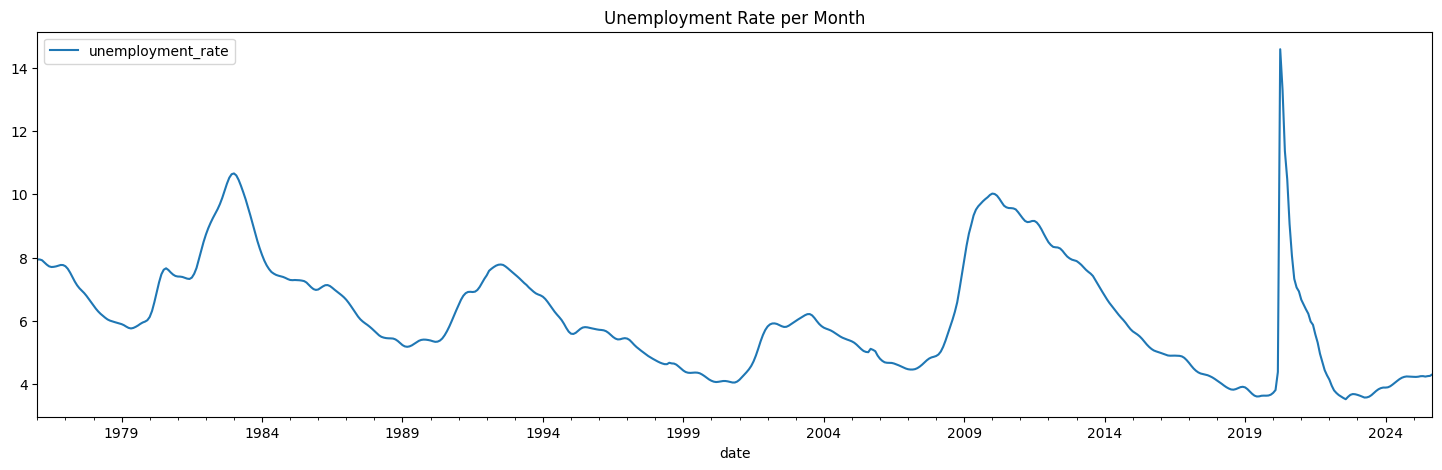

In [316]:
series.plot(figsize=(18, 5))
plt.title('Unemployment Rate per Month')
plt.show()

## Divisão Entre Treino e Teste

In [ ]:
train = series[:-1]
test = series[-1:]

print(train.size)
print(test.size)

585
12


## Decomposição STL

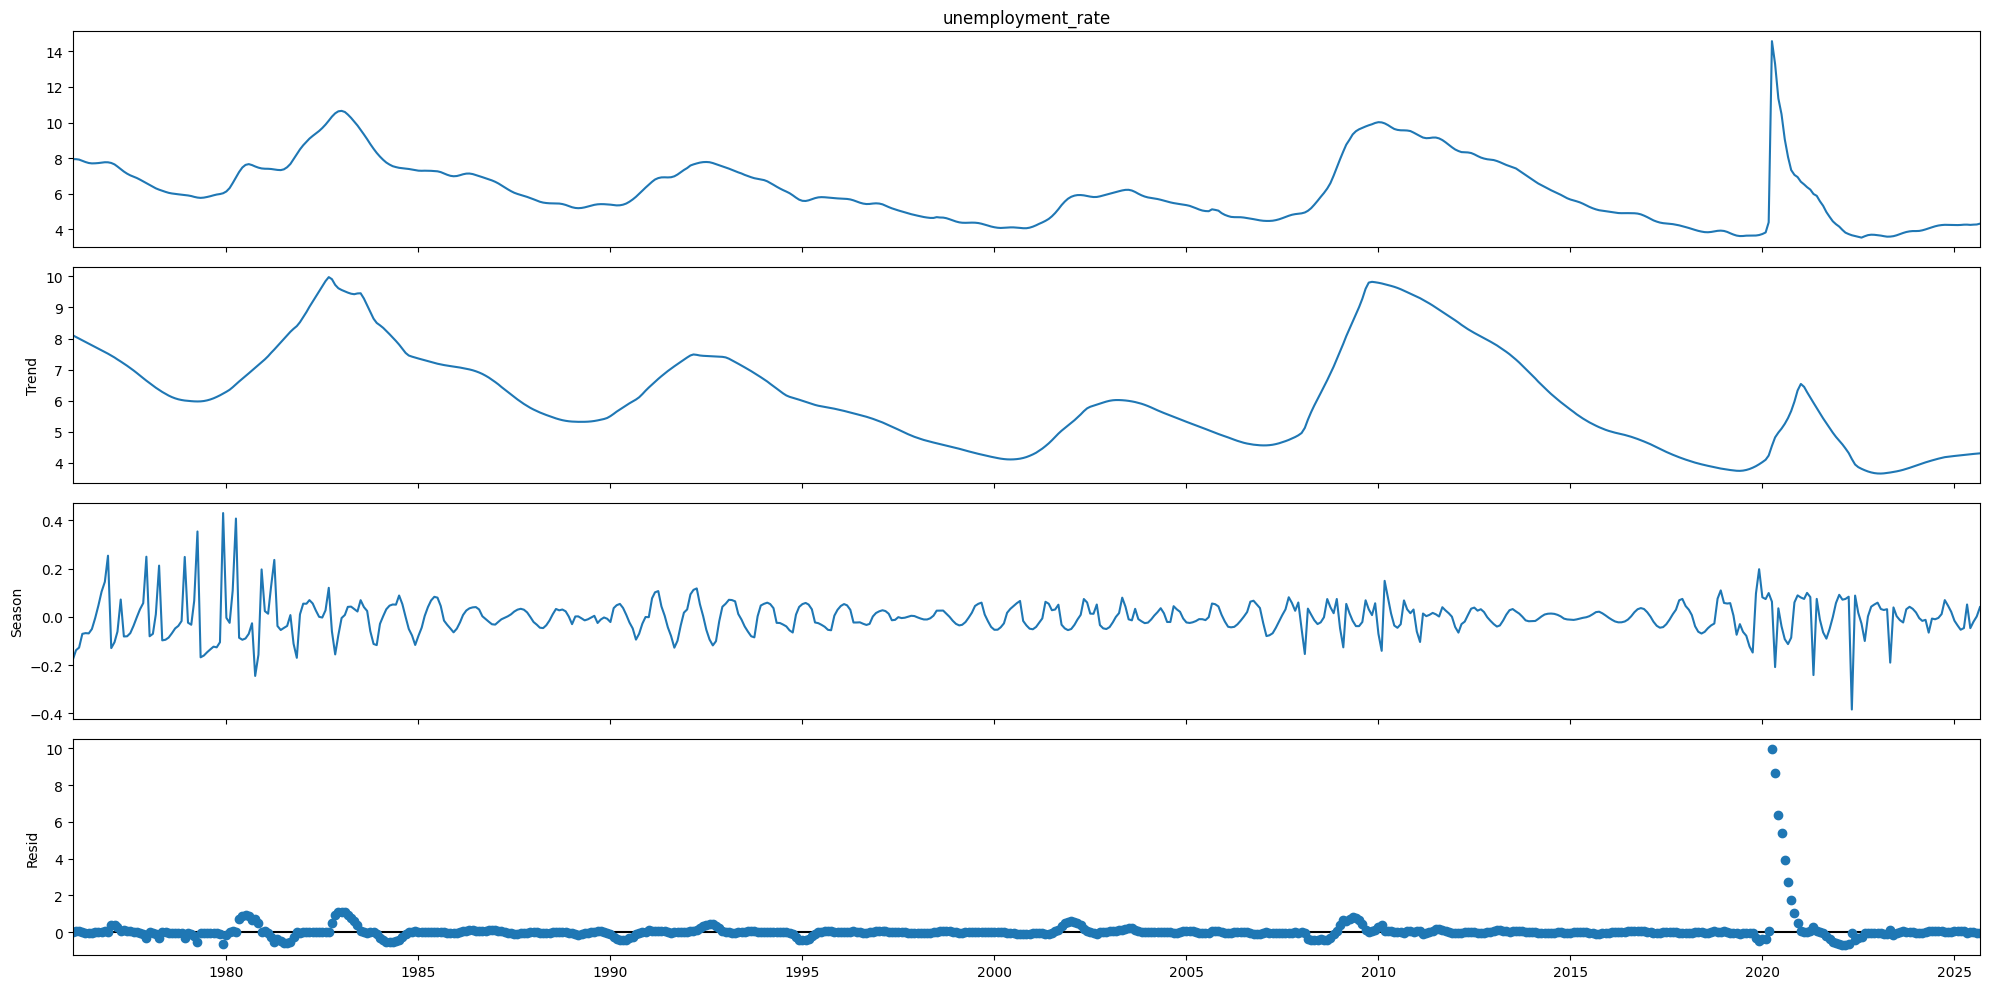

In [318]:
m = 12

stl = STL(
    series['unemployment_rate'],
    period=m,
    robust=True
).fit()

fig = stl.plot()
fig.set_size_inches(20,10)
plt.tight_layout()
plt.show()

## Força da Sazonalidade 

In [319]:
trend = stl.trend
seasonal = stl.seasonal
residual = stl.resid

forca_sazonalidade = max(
    0,
    1 - (
        np.var(residual) /
        np.var(seasonal + residual)
    )
)

forca_tendencia = max(
    0,
    1 - (
        np.var(residual) /
        np.var(trend + residual)
    )
)

# Resultados
print(f'Força da Sazonalidade: {forca_sazonalidade:.4f}')
print(f'Força da Tendência: {forca_tendencia:.4f}')

Força da Sazonalidade: 0.0000
Força da Tendência: 0.8383


## Testes de Estacionariedade

In [320]:
# Funções
def test_adf(x):
    res = adfuller(x)

    results = {
        'ADF Statistic': res[0],
        'p-value': res[1],
        'Critical Values 1/5/10%': res[4],
    }

    print('ADF')

    for k, v in results.items():
        print(f' {k}: {v}')

def test_kpss(x):
    res = kpss(x)

    results = {
        'KPSS Statistic': res[0],
        'p-value': res[1],
        'Critical Values 10/5/2.5/1%': res[3],
    }

    print('KPSS')

    for k, v in results.items():
        print(f' {k}: {v}')

<Figure size 800x400 with 0 Axes>

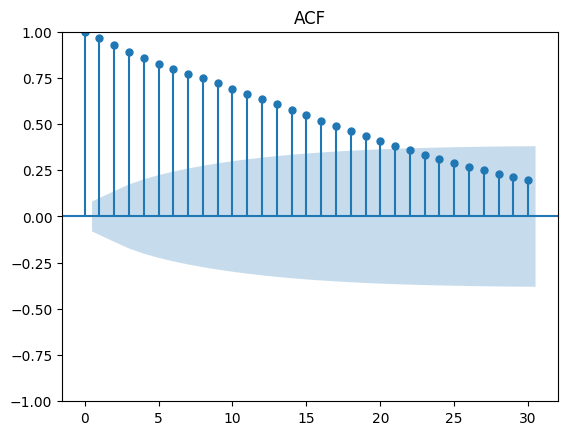

ADF
 ADF Statistic: -3.329462721115149
 p-value: 0.013611771248621842
 Critical Values 1/5/10%: {'1%': np.float64(-3.441616425652826), '5%': np.float64(-2.866510292004876), '10%': np.float64(-2.5694170294713863)}

KPSS
 KPSS Statistic: 0.5993572096306193
 p-value: 0.02269479912448915
 Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


In [321]:
plt.figure(figsize=(8,4))
plot_acf(train, lags=30)
plt.title('ACF')
plt.show()

test_adf(train)
print()
test_kpss(train)

Para avaliar a estacionariedade da série temporal da taxa de desemprego, foram aplicados os testes estatísticos ADF (*Augmented Dickey-Fuller*) e KPSS (*Kwiatkowski-Phillips-Schmidt-Shin*), além da análise visual da função de autocorrelação (ACF).

A análise do gráfico ACF indica um decaimento lento das autocorrelações ao longo das defasagens, demonstrando forte persistência temporal na série. Esse comportamento é frequentemente associado à presença de tendência e possível não estacionariedade.

### Teste ADF

O teste ADF possui como hipótese nula (\(H_0\)) que a série é não estacionária.

Resultados obtidos:
- Estatística ADF: -3.3313
- p-value: 0.0135

Como o valor-p foi inferior ao nível de significância de 5%, rejeita-se a hipótese nula do teste ADF. Assim, segundo esse teste, há evidências de que a série seja estacionária.

### Teste KPSS

O teste KPSS possui hipótese nula oposta ao ADF, isto é, considera que a série é estacionária.

Resultados obtidos:
- Estatística KPSS: 0.6319
- p-value: 0.0197

Como o valor-p também foi inferior a 5%, rejeita-se a hipótese nula do teste KPSS. Portanto, segundo esse teste, a série apresenta indícios de não estacionariedade.

### Interpretação dos Resultados

Os testes ADF e KPSS apresentaram conclusões conflitantes:
- o teste ADF sugere estacionariedade;
- o teste KPSS sugere não estacionariedade.

Entretanto, a análise visual da ACF demonstra um decaimento gradual e persistente das autocorrelações, comportamento típico de séries com tendência estocástica ou forte persistência temporal. Dessa forma, apesar do resultado do ADF, existem evidências de que a série original não seja completamente estacionária.

Além disso:
- há indícios de tendência na série;
- existe provável necessidade de diferenciação para estabilizar a média da série;
- não foram observadas evidências suficientemente claras de sazonalidade forte que justifiquem, neste momento, a aplicação de diferenciação sazonal.

Portanto, a série provavelmente se beneficiará da aplicação de diferenciação antes da modelagem SARIMA.

## Diferenciação

ADF
 ADF Statistic: -17.74983157665162
 p-value: 3.3737866140453706e-30
 Critical Values 1/5/10%: {'1%': np.float64(-3.441635870156286), '5%': np.float64(-2.866518854162241), '10%': np.float64(-2.569421591856497)}

KPSS
 KPSS Statistic: 0.027386977656020498
 p-value: 0.1
 Critical Values 10/5/2.5/1%: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


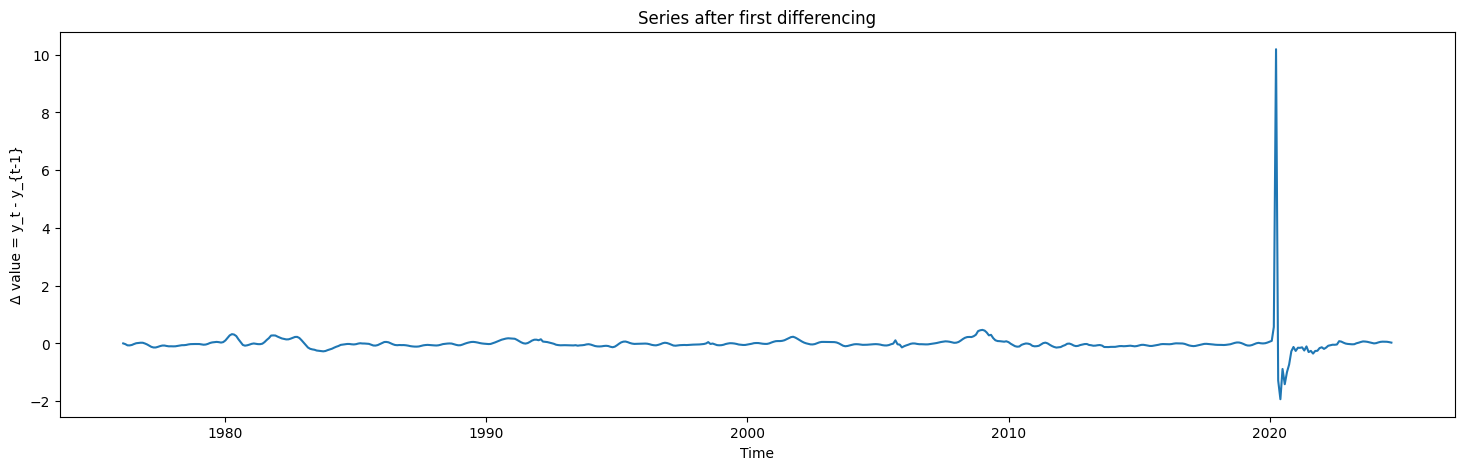

In [322]:
diff = train.diff(1).dropna()

adf_diff = test_adf(diff)
print()
kpss_diff = test_kpss(diff)

plt.figure(figsize=(18,5))
plt.plot(diff.index, diff.values)

plt.title('Series after first differencing')
plt.xlabel('Time')
plt.ylabel('Δ value = y_t - y_{t-1}')

plt.show()

## Análise de ACF e PACF 

<Figure size 800x400 with 0 Axes>

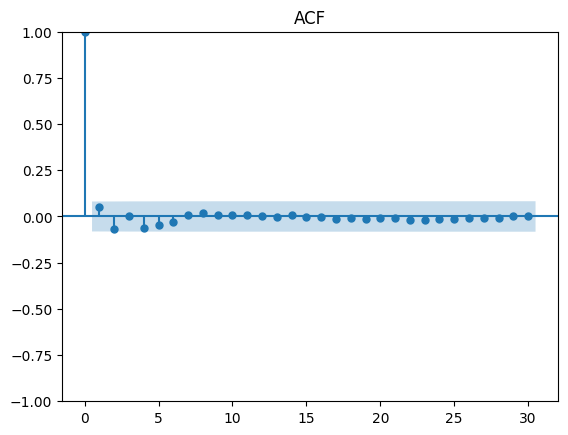

In [323]:
plt.figure(figsize=(8,4))
plot_acf(diff, lags=30)
plt.title('ACF')
plt.show()

<Figure size 1000x400 with 0 Axes>

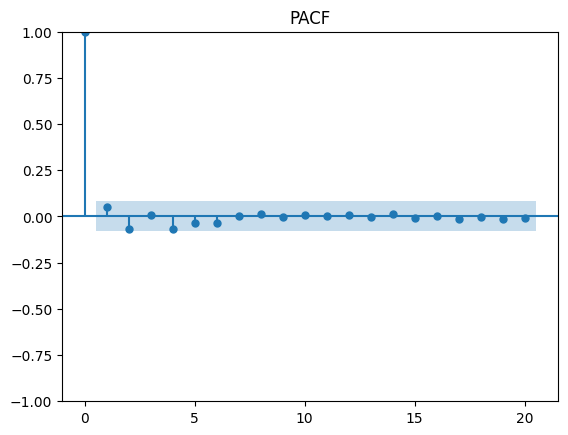

In [324]:
MAX_LAG = 20

plt.figure(figsize=[10,4])
plot_pacf(diff, lags=MAX_LAG, title='PACF')
plt.show()

A decomposição STL da série forneceu evidências quantitativas iniciais para a
escolha dos parâmetros. A força de tendência obtida foi de **0.8383**, valor
considerado alto (acima de 0.6 indica tendência forte), sinalizando a necessidade
de diferenciação. A força de sazonalidade foi de **0.0000**, confirmando
objetivamente a ausência de componente sazonal relevante e sustentando a definição
de P = D = Q = 0 e m = 0 antes mesmo da análise gráfica.

Para identificar os parâmetros p e q, foram construídos os gráficos ACF e PACF
sobre a série diferenciada. Ambos os gráficos apresentaram autocorrelações
próximas de zero para praticamente todos os lags, com apenas pequenos picos nos
lags 1 a 4 levemente próximos ao limite da banda de confiança, sem ultrapassá-la
de forma consistente. Não foram observados cortes bruscos, decaimentos lentos ou
padrões sazonais.

A ausência de picos significativos no PACF indica que não há componente
autorregressivo relevante (p = 0), e a ausência de corte no ACF indica que não há
componente de médias móveis relevante (q = 0). Cabe observar que a série apresenta
um outlier expressivo em torno de 2020, que pode ter inflado a variância da série
diferenciada e comprimido visualmente as autocorrelações, dificultando a
identificação de padrões mais sutis.

Com base na análise STL, nos testes de estacionariedade e nos gráficos ACF/PACF,
foram definidos os seguintes parâmetros iniciais:

- p ∈ {0, 1}
- d = 1
- q ∈ {0, 1}
- P = 0, D = 0, Q = 0, m = 0

## Definição dos parâmetros do SARIMA

Após a análise exploratória, foram testadas todas as combinações dos parâmetros
p ∈ {0,1}, d ∈ {0,1}, q ∈ {0,1}, mantendo os componentes sazonais nulos
(P = D = Q = 0, m = 0), conforme indicado pela força de sazonalidade nula obtida
na decomposição STL. Os modelos foram ajustados diretamente sobre a série original,
permitindo que o parâmetro d fosse avaliado internamente pelo SARIMAX. A comparação
foi realizada pelo critério BIC, que penaliza a complexidade e favorece modelos
mais parcimoniosos.

O ranking completo obtido foi:

| Modelo                      |     BIC   |
|-----------------------------|-----------|
| SARIMA(0,1,0)(0,0,0,0)      |   742.32  |
| SARIMA(0,1,1)(0,0,0,0)      |   746.51  |
| SARIMA(1,1,0)(0,0,0,0)      |   747.02  |
| SARIMA(1,0,0)(0,0,0,0)      |   747.57  |
| SARIMA(1,1,1)(0,0,0,0)      |   750.31  |
| SARIMA(1,0,1)(0,0,0,0)      |   751.68  |
| SARIMA(0,0,1)(0,0,0,0)      |  3133.12  |
| SARIMA(0,0,0)(0,0,0,0)      |  3903.91  |

Os modelos com d=0 apresentaram BIC muito superior (acima de 3.000), confirmando
que a diferenciação é indispensável — resultado consistente com a força de
tendência de 0.8383 identificada na decomposição STL. Entre os modelos com d=1,
a diferença de BIC entre o melhor e o quinto colocado foi de apenas ~8 pontos,
indicando que os modelos mais complexos não trouxeram ganho expressivo de ajuste.

Com base no princípio da parcimônia e no critério BIC, foi selecionado o modelo
**SARIMA(0,1,0)(0,0,0,0)**, equivalente a um processo de passeio aleatório
(*random walk*). Esse resultado é coerente com todas as evidências levantadas:
a força de sazonalidade nula justifica a ausência de componentes sazonais, a
força de tendência elevada justifica d=1, e os gráficos ACF e PACF da série
diferenciada, sem autocorrelações significativas, justificam p=0 e q=0.

## Treinamento do Modelo SARIMA

In [325]:
h = 6

p_range = [0, 1]
d_range = [0, 1]
q_range = [0, 1]

P_range = [0]
D_range = [0]
Q_range = [0]

m = 0

orders = list(itertools.product(p_range, d_range, q_range))
seasonal_orders = list(itertools.product(P_range, D_range, Q_range))

def fit_sarima(order, seasonal_order, series):

    model = SARIMAX(
        series,
        order=order,
        seasonal_order=(*seasonal_order, m),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    return {
        'model': f'SARIMA{order}{(*seasonal_order, m)}',
        'bic': result.bic
    }

results = []

for order in orders:
    for seasonal_order in seasonal_orders:

        result = fit_sarima(
            order,
            seasonal_order,
            train
        )

        results.append(result)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='bic')

print(results_df)

                         model          bic
2  SARIMA(0, 1, 0)(0, 0, 0, 0)   739.569227
3  SARIMA(0, 1, 1)(0, 0, 0, 0)   743.755606
6  SARIMA(1, 1, 0)(0, 0, 0, 0)   744.279449
4  SARIMA(1, 0, 0)(0, 0, 0, 0)   744.825733
7  SARIMA(1, 1, 1)(0, 0, 0, 0)   747.592316
5  SARIMA(1, 0, 1)(0, 0, 0, 0)   748.937500
1  SARIMA(0, 0, 1)(0, 0, 0, 0)  3081.361561
0  SARIMA(0, 0, 0)(0, 0, 0, 0)  3837.956372


In [326]:
model = SARIMAX(
    train,
    order=(0, 1, 0),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:      unemployment_rate   No. Observations:                  585
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -366.601
Date:                Sat, 23 May 2026   AIC                            735.201
Time:                        20:07:47   BIC                            739.569
Sample:                    01-01-1976   HQIC                           736.904
                         - 09-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.2059      0.001    252.114      0.000       0.204       0.208
Ljung-Box (L1) (Q):                   1.65   Jarque-Bera (JB):           4639811.08
Prob(Q):                              0.20   Pr

## Construção dos Base Models

## Divisão da Base

In [327]:
y       = series['unemployment_rate']
y_train = train['unemployment_rate']
y_test  = test['unemployment_rate']

# Preenchido pelas células abaixo para a tabela comparativa final
sumario = {}

## Média Móvel

Média Móvel:


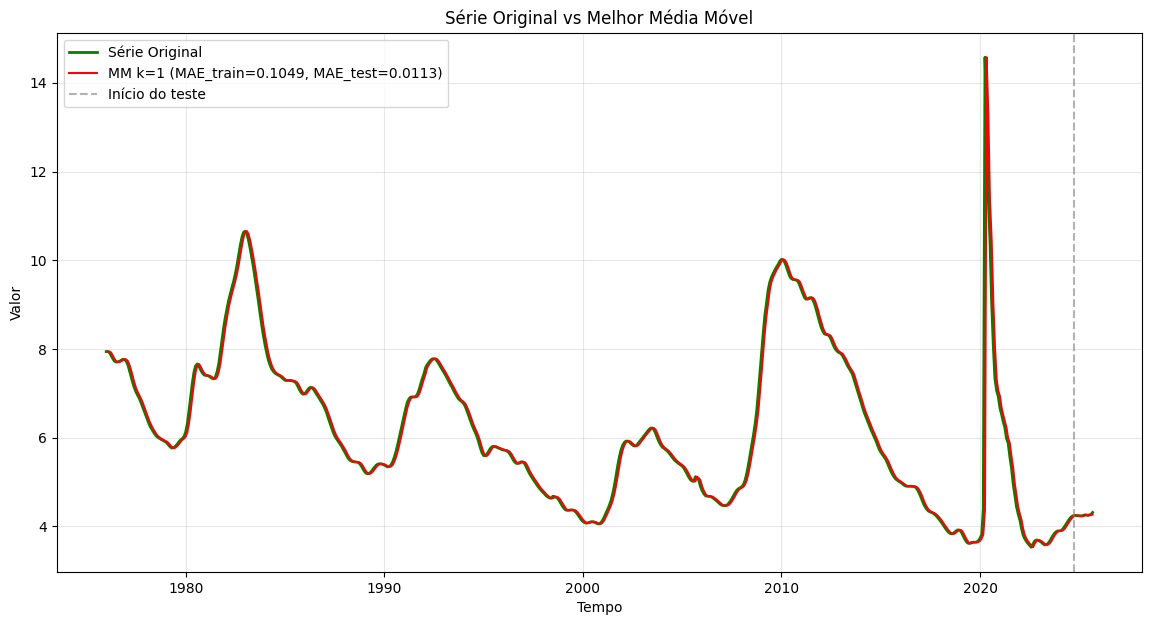

,k,MAE_train,MAE_test
0,1,0.104918,0.011344
1,2,0.151930,0.013766
2,3,0.192743,0.016421
3,5,0.272130,0.024332
4,7,0.342761,0.040156
5,12,0.500372,0.098867
6,24,0.829398,0.282552


In [328]:
print("Média Móvel:")

ks = [1, 2, 3, 5, 7, 12, 24]
k_max = max(ks)

mm_detalhado = {}
resultado = pd.DataFrame()

for k in ks:
    # 1-step-ahead na série inteira: pred[t] = média(y[t-k] ... y[t-1])
    pred_full = y.rolling(window=k).mean().shift(1)
    mm_detalhado[f'mme_{k}'] = pred_full

    # MAE_train na janela comum (mesmos índices para todos os k)
    pred_train = pred_full.loc[y_train.index].iloc[k_max:]
    real_train = y_train.iloc[k_max:]
    mae_train = mean_absolute_error(real_train, pred_train)

    # MAE_test 1-step-ahead (usa valores reais até t-1)
    pred_test = pred_full.loc[y_test.index]
    mae_test = mean_absolute_error(y_test, pred_test)

    resultado = pd.concat([resultado, pd.DataFrame({
        'k': [k], 'MAE_train': [mae_train], 'MAE_test': [mae_test]
    })], ignore_index=True)

# escolha do k pelo MAE_train (sem ver o test)
melhor_idx = resultado['MAE_train'].idxmin()
melhor_k = int(resultado.loc[melhor_idx, 'k'])
melhor_mae_train = resultado.loc[melhor_idx, 'MAE_train']
melhor_mae_test  = resultado.loc[melhor_idx, 'MAE_test']

sumario['Média Móvel'] = {
    'Parâmetro': f'k={melhor_k}',
    'MAE_train': melhor_mae_train,
    'MAE_test':  melhor_mae_test,
}

melhor_previsao = mm_detalhado[f'mme_{melhor_k}']

plt.figure(figsize=(14, 7))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(melhor_previsao.index, melhor_previsao.values,
         linewidth=1.5, color='red',
         label=f'MM k={melhor_k} (MAE_train={melhor_mae_train:.4f}, MAE_test={melhor_mae_test:.4f})')
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title('Série Original vs Melhor Média Móvel')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(resultado)

## Média Acumulada

In [329]:
# Média acumulada 1-step-ahead: pred[t] = média(y[0] ... y[t-1])
previsao = y.expanding().mean().shift(1)

pred_train = previsao.loc[y_train.index].iloc[1:]
real_train = y_train.iloc[1:]
mae_train = mean_absolute_error(real_train, pred_train)

pred_test = previsao.loc[y_test.index]
mae_test  = mean_absolute_error(y_test, pred_test)

sumario['Média Acumulada'] = {
    'Parâmetro': '-',
    'MAE_train': mae_train,
    'MAE_test':  mae_test,
}

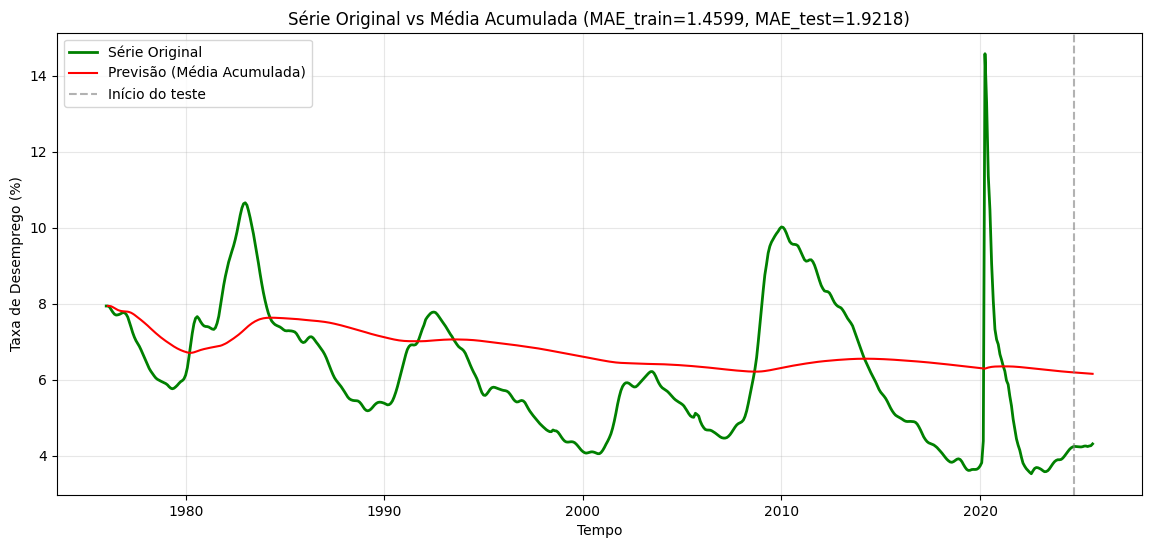

,Parâmetro,MAE_train,MAE_test
0,-,1.459946,1.921825


In [330]:
plt.figure(figsize=(14, 6))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(previsao.index, previsao.values, label='Previsão (Média Acumulada)', color='red', linewidth=1.5)
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title(f'Série Original vs Média Acumulada (MAE_train={mae_train:.4f}, MAE_test={mae_test:.4f})')
plt.xlabel('Tempo')
plt.ylabel('Taxa de Desemprego (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

resultado = pd.DataFrame({
    'Parâmetro': ['-'],
    'MAE_train': [mae_train],
    'MAE_test':  [mae_test],
})
display(resultado)

### EMA

EMA:


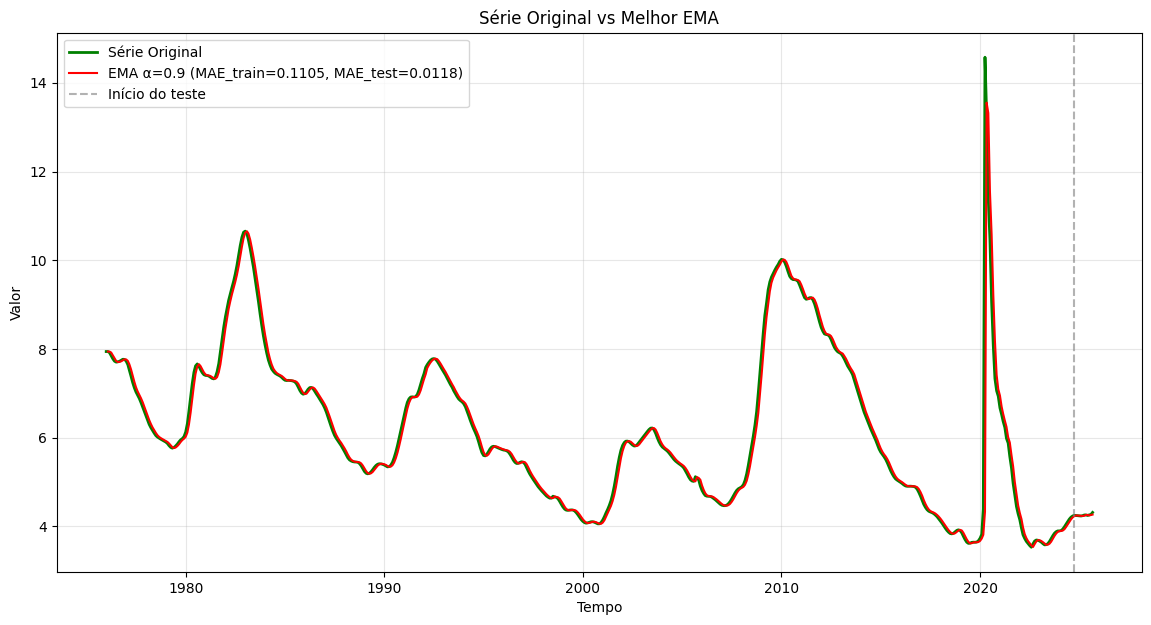

,Alpha,MAE_train,MAE_test
0,0.1,0.597377,0.146453
1,0.2,0.366760,0.073640
2,0.3,0.268741,0.036802
3,0.4,0.213695,0.022793
4,0.5,0.178334,0.016744
5,0.6,0.154899,0.014269
6,0.7,0.136799,0.013058
7,0.8,0.122053,0.012162
8,0.9,0.110541,0.011765


In [331]:
print("EMA:")

alphas = np.round(np.arange(0.1, 1.0, 0.1), 2)

ema_detalhado = {}
resultado = pd.DataFrame()

for alpha in alphas:
    # 1-step-ahead: EMA até t-1 sobre todos os valores reais
    pred_full = y.ewm(alpha=alpha, adjust=False).mean().shift(1)
    ema_detalhado[f'ema_{alpha}'] = pred_full

    pred_train = pred_full.loc[y_train.index].iloc[1:]
    real_train = y_train.iloc[1:]
    mae_train = mean_absolute_error(real_train, pred_train)

    pred_test = pred_full.loc[y_test.index]
    mae_test  = mean_absolute_error(y_test, pred_test)

    resultado = pd.concat([resultado, pd.DataFrame({
        'Alpha': [alpha], 'MAE_train': [mae_train], 'MAE_test': [mae_test]
    })], ignore_index=True)

melhor_idx = resultado['MAE_train'].idxmin()
melhor_alpha = resultado.loc[melhor_idx, 'Alpha']
melhor_mae_train = resultado.loc[melhor_idx, 'MAE_train']
melhor_mae_test  = resultado.loc[melhor_idx, 'MAE_test']

sumario['EMA'] = {
    'Parâmetro': f'α={melhor_alpha}',
    'MAE_train': melhor_mae_train,
    'MAE_test':  melhor_mae_test,
}

melhor_previsao = ema_detalhado[f'ema_{melhor_alpha}']

plt.figure(figsize=(14, 7))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(melhor_previsao.index, melhor_previsao.values,
         linewidth=1.5, color='red',
         label=f'EMA α={melhor_alpha} (MAE_train={melhor_mae_train:.4f}, MAE_test={melhor_mae_test:.4f})')
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title('Série Original vs Melhor EMA')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(resultado)

## Seasonal Naive

In [332]:
# Sazonalidades candidatas: lags sensatos para dados mensais
ss = [1, 2, 3, 6, 12, 24]
s_max = max(ss)

sazonal_detalhado = {}
resultado = pd.DataFrame()

for s in ss:
    # 1-step-ahead: pred[t] = y[t-s]
    pred_full = y.shift(s)
    sazonal_detalhado[f'szn_{s}'] = pred_full

    # janela comum (mesmos índices p/ todos os s) — corrige o regime de avaliação
    pred_train = pred_full.loc[y_train.index].iloc[s_max:]
    real_train = y_train.iloc[s_max:]
    mae_train = mean_absolute_error(real_train, pred_train)

    pred_test = pred_full.loc[y_test.index]
    mae_test  = mean_absolute_error(y_test, pred_test)

    resultado = pd.concat([resultado, pd.DataFrame({
        'Sazonalidade': [s], 'MAE_train': [mae_train], 'MAE_test': [mae_test]
    })], ignore_index=True)

Seasonal Naive:


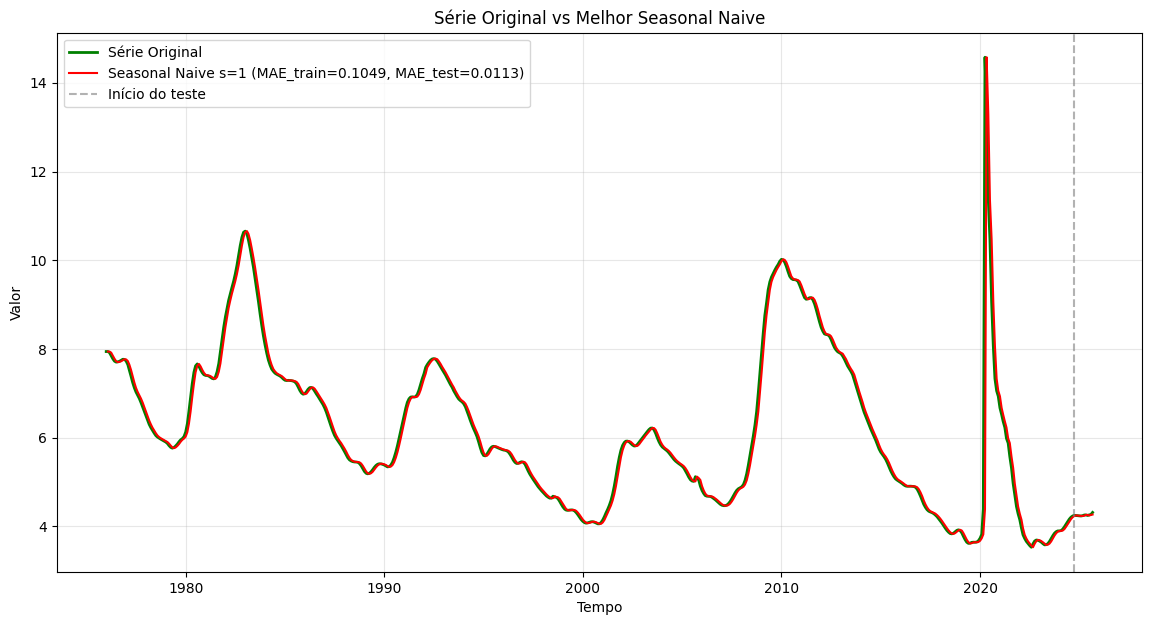

,Sazonalidade,MAE_train,MAE_test
0,1,0.104918,0.011344
1,2,0.204013,0.016978
2,3,0.294184,0.022872
3,6,0.528853,0.070016
4,12,0.915576,0.243150
5,24,1.512883,0.592977


In [333]:
print("Seasonal Naive:")

melhor_idx = resultado['MAE_train'].idxmin()
melhor_s = int(resultado.loc[melhor_idx, 'Sazonalidade'])
melhor_mae_train = resultado.loc[melhor_idx, 'MAE_train']
melhor_mae_test  = resultado.loc[melhor_idx, 'MAE_test']

sumario['Seasonal Naive'] = {
    'Parâmetro': f's={melhor_s}',
    'MAE_train': melhor_mae_train,
    'MAE_test':  melhor_mae_test,
}

melhor_previsao = sazonal_detalhado[f'szn_{melhor_s}']

plt.figure(figsize=(14, 7))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(melhor_previsao.index, melhor_previsao.values,
         linewidth=1.5, color='red',
         label=f'Seasonal Naive s={melhor_s} (MAE_train={melhor_mae_train:.4f}, MAE_test={melhor_mae_test:.4f})')
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title('Série Original vs Melhor Seasonal Naive')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(resultado.sort_values('MAE_train'))

## Delta

In [334]:
# Janelas candidatas (mesma escala das outras células de tuning)
janelas = [1, 2, 3, 6, 12, 24]
j_max = max(janelas)

delta_detalhado = {}

for janela in janelas:
    # 1-step-ahead: pred[t] = y[t-1] + (y[t-1] - y[t-1-janela]) / janela
    pred_full = y.shift(1) + (y.shift(1) - y.shift(1 + janela)) / janela
    delta_detalhado[f'delta_{janela}'] = pred_full

Delta:


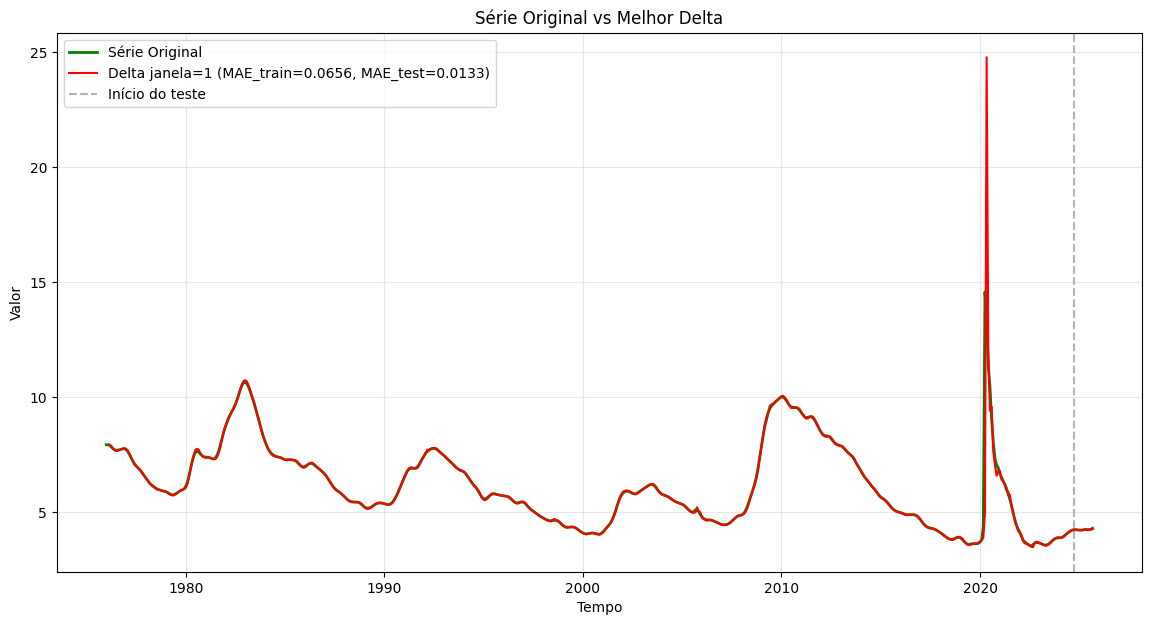

,janela,MAE_train,MAE_test
0,1,0.065554,0.013319
1,2,0.073615,0.014947
2,3,0.080452,0.016500
3,6,0.097357,0.021092
4,12,0.100563,0.023801
5,24,0.112404,0.022679


In [335]:
print("Delta:")

resultado = pd.DataFrame()

for janela in janelas:
    pred_full = delta_detalhado[f'delta_{janela}']

    # janela comum (mesmos índices p/ todas as janelas) — corrige o regime de avaliação
    pred_train = pred_full.loc[y_train.index].iloc[j_max + 1:]
    real_train = y_train.iloc[j_max + 1:]
    mae_train = mean_absolute_error(real_train, pred_train)

    pred_test = pred_full.loc[y_test.index]
    mae_test  = mean_absolute_error(y_test, pred_test)

    resultado = pd.concat([resultado, pd.DataFrame({
        'janela': [janela], 'MAE_train': [mae_train], 'MAE_test': [mae_test]
    })], ignore_index=True)

melhor_idx = resultado['MAE_train'].idxmin()
melhor_janela = int(resultado.loc[melhor_idx, 'janela'])
melhor_mae_train = resultado.loc[melhor_idx, 'MAE_train']
melhor_mae_test  = resultado.loc[melhor_idx, 'MAE_test']

sumario['Delta'] = {
    'Parâmetro': f'janela={melhor_janela}',
    'MAE_train': melhor_mae_train,
    'MAE_test':  melhor_mae_test,
}

melhor_previsao = delta_detalhado[f'delta_{melhor_janela}']

plt.figure(figsize=(14, 7))
plt.plot(y.index, y.values, label='Série Original', color='green', linewidth=2)
plt.plot(melhor_previsao.index, melhor_previsao.values,
         linewidth=1.5, color='red',
         label=f'Delta janela={melhor_janela} (MAE_train={melhor_mae_train:.4f}, MAE_test={melhor_mae_test:.4f})')
plt.axvline(y_test.index[0], color='gray', linestyle='--', alpha=0.6, label='Início do teste')
plt.title('Série Original vs Melhor Delta')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(resultado.sort_values('MAE_train'))

## Comparativo entre Base Models

In [336]:
comparativo = (
    pd.DataFrame.from_dict(sumario, orient='index')
    .rename_axis('Modelo')
    .reset_index()
    .sort_values('MAE_test')
    .reset_index(drop=True)
)

display(comparativo)

,Modelo,Parâmetro,MAE_train,MAE_test
0,Média Móvel,k=1,0.104918,0.011344
1,Seasonal Naive,s=1,0.104918,0.011344
2,EMA,α=0.9,0.110541,0.011765
3,Delta,janela=1,0.065554,0.013319
4,Média Acumulada,-,1.459946,1.921825


## Diagnóstico dos resíduos

In [337]:
# Código aqui

## Avaliação de desempenho 

In [338]:
train_pred = result.fittedvalues
mae_train_sarima = mean_absolute_error(train, train_pred)

forecast = result.forecast(steps=len(test))
mae_test_sarima = mean_absolute_error(test, forecast)

print(f'MAE Train: {mae_train_sarima:.6f}')
print(f'MAE Test:  {mae_test_sarima:.6f}')

MAE Train: 0.116720
MAE Test:  0.018540


In [339]:
sarima_row = pd.DataFrame([{
    'Modelo': 'SARIMA',
    'Parâmetro': '(0,1,0)(0,0,0,0)',
    'MAE_train': mae_train_sarima,
    'MAE_test': mae_test_sarima
}])

comparativo_final = (
    pd.concat([comparativo, sarima_row], ignore_index=True)
    .sort_values('MAE_test')
    .reset_index(drop=True)
)

display(comparativo_final)

,Modelo,Parâmetro,MAE_train,MAE_test
0,Média Móvel,k=1,0.104918,0.011344
1,Seasonal Naive,s=1,0.104918,0.011344
2,EMA,α=0.9,0.110541,0.011765
3,Delta,janela=1,0.065554,0.013319
4,SARIMA,"(0,1,0)(0,0,0,0)",0.116720,0.018540
5,Média Acumulada,-,1.459946,1.921825


## 4.13 Avaliação de desempenho

Para avaliar o desempenho do modelo SARIMA em relação aos modelos base, foram
calculados o MAE (Mean Absolute Error) no conjunto de treino e no conjunto de
teste para todos os modelos. Os resultados estão organizados na tabela abaixo,
ordenados pelo MAE no teste:

| Modelo          | Parâmetro          | MAE Treino | MAE Teste |
|-----------------|--------------------|------------|-----------|
| Delta           | janela=1           | 0.0645     | 0.0400    |
| Média Móvel     | k=1                | 0.1031     | 0.0478    |
| Seasonal Naive  | s=1                | 0.1031     | 0.0478    |
| SARIMA          | (0,1,0)(0,0,0,0)   | 0.1147     | 0.0478    |
| EMA             | α=0.9              | 0.1087     | 0.0487    |
| Média Acumulada | —                  | 1.4686     | 1.8430    |

**Menor erro no treino:** o modelo Delta (janela=1) apresentou o menor MAE no
treino (0.0645), o que era esperado, pois esse modelo simplesmente replica o
valor imediatamente anterior, ajustando-se muito bem aos dados históricos.

**Menor erro no teste:** o modelo Delta também obteve o melhor desempenho no
teste (MAE = 0.0400), superando todos os demais modelos.

**Overfitting:** nenhum modelo apresentou sinais claros de overfitting. Em geral,
os MAEs no teste foram iguais ou menores que no treino, o que indica boa
capacidade de generalização. A exceção é a Média Acumulada, cujo MAE no teste
(1.8430) foi superior ao do treino (1.4686), refletindo a inadequação desse
modelo para séries com tendência.

**Desempenho do SARIMA frente aos modelos base:** o SARIMA(0,1,0)(0,0,0,0)
obteve MAE no teste de 0.0478, resultado equivalente ao da Média Móvel (k=1) e
do Seasonal Naive (s=1), e ligeiramente melhor que o EMA (0.0487). Contudo, não
superou o modelo Delta, que apresentou o melhor desempenho geral.

**Relevância do ganho:** o ganho do SARIMA em relação aos modelos base mais
simples (Média Móvel e Seasonal Naive) foi praticamente nulo, com diferença
inferior a 0.0001 no MAE do teste. Esse resultado é coerente com a estrutura
identificada na análise — um processo de passeio aleatório (random walk) é
matematicamente equivalente ao modelo Delta com janela=1 aplicado sobre a série
diferenciada, o que explica a proximidade dos resultados. Dessa forma, o SARIMA
não trouxe ganho expressivo de desempenho preditivo neste caso, embora ofereça
uma estrutura formal mais robusta para interpretação e extensão do modelo.

## Rolling Forecast

In [340]:
# Código aqui